# Прогноз волатильности: HAR-RV против EWMA движка

Волатильность — единственный по-настоящему прогнозируемый объект на рынке
(кластеризация волы — самый устойчивый стилизованный факт финансов). Движок сейчас
таргетирует волу через EWMA(λ=0.06) — это простейший прогноз. Вопрос: даёт ли
**HAR-RV** (реализованная вола трёх горизонтов — день/неделя/месяц, три
коэффициента, стандарт индустрии) прогноз лучше, и переводится ли это в деньги.

**Два объекта:**
1. **Портфель топ-5 альф** — то, что реально таргетирует движок. Здесь RV-прокси —
   дневной r² (внутридневную RV стратегии без интрадей-позиций не построить).
2. **BTC с настоящей внутридневной RV** из data_1h.pickle (24 часовых бара в день) —
   учебный случай: показывает потолок прогнозируемости, когда HAR кормят честной RV.

**Протокол:** walk-forward (рефит HAR каждые 63 бара, расширяющееся окно), лосс —
**QLIKE** (робастный стандарт для сравнения вол-прогнозов; ниже = лучше) + MSE +
Минсер-Зарновиц R². Деньги: ре-таргетинг портфеля к 36% каждым прогнозом
(лаг 1 бар, плечо ≤ 2, 10 б.п. за смену размера) → Sharpe / maxDD /
**ошибка удержания целевой волы**.

In [1]:
import os, sys, json, warnings, difflib, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore'); np.seterr(all='ignore')
PROJ = os.getcwd()
S = json.load(open(os.path.join(PROJ, 'alphanode', 'gui_settings.json')))
TF = S.get('timeframe', '1d')
os.environ['ALPHANODE_TF'] = TF
sys.path[:0] = [os.path.join(PROJ, 'evolution'), PROJ]
from config import load_config
from evaluator import build_panel, make_market, eval_alpha_panel
from fastsim import fast_sim
from genome import parse

cfg = load_config()
ANN, FREQ = float(cfg.get('ann', 365.0)), cfg.get('freq', 'D')
VOL, EXEC = float(S['target_vol']), float(S['exec_cost'])
DATA = os.path.join(PROJ, 'data.pickle' if TF == '1d' else f'data_{TF}.pickle')
LIB = os.path.join(PROJ, 'alphanode', 'state',
                   'library.jsonl' if TF == '1d' else f'library_{TF}.jsonl')
TR, VA, TE, EN = (pd.Timestamp(S[k], tz='UTC') for k in
                  ('train_start', 'val_start', 'test_start', 'test_end'))
LAM, WF_START, WF_STEP, SIZE_COST, LEV_CAP = 0.06, 500, 63, 0.0010, 2.0
EPS = 1e-10
print(f'engine EWMA lambda={LAM} · target vol {VOL:.0%} · WF start {WF_START} step {WF_STEP}')

engine EWMA lambda=0.06 · target vol 36% · WF start 500 step 63


In [2]:
rows = [json.loads(l) for l in open(LIB, encoding='utf-8')]
rows = [r for r in rows if r.get('formula') and isinstance(r.get('base'), (int, float))]
rows.sort(key=lambda c: c['base'], reverse=True)
picked = []
for c in rows:
    if all(difflib.SequenceMatcher(None, c['formula'], p['formula']).ratio() < 0.80
           for p in picked):
        picked.append(c)
    if len(picked) == 5:
        break
tk, raw, panel = build_panel(DATA, TR.tz_localize(None).to_pydatetime(),
                             EN.tz_localize(None).to_pydatetime(), None, freq=FREQ)
market = make_market(panel, tk, raw, vol_window=cfg.get('vol_window', 30))
R = {}
for c in picked:
    ap = eval_alpha_panel(parse(c['formula']), panel)
    R[c['formula'][:40]] = fast_sim(ap[tk].to_numpy(dtype=np.float64), market, VOL, EXEC,
                                    ann=ANN, ewma_lambda=cfg.get('ewma_lambda', 0.06))
p = pd.DataFrame(R).fillna(0.0).mean(axis=1)
idx = p.index
print(f'{len(p)} daily bars of the top-5 EW portfolio')

2496 daily bars of the top-5 EW portfolio


## 1. Прогнозы волы портфеля: EWMA(0.06) · rolling-21 · HAR-lite

Все прогнозы делаются на баре t для бара t+1, строго из прошлого. HAR
переобучается walk-forward в лог-пространстве.

In [3]:
def ewma_var(r, lam):
    # the engine's recursion: var_t = lam*r_t^2 + (1-lam)*var_{t-1}; forecast for t+1
    v = np.empty(len(r)); v[:] = np.nan
    prev = np.nanvar(r[:30]) if len(r) > 30 else (r[:5] ** 2).mean()
    for i, x in enumerate(r):
        prev = lam * x * x + (1 - lam) * prev
        v[i] = prev
    return v

def har_forecast(rv, wf_start=WF_START, step=WF_STEP):
    # log-HAR: log rv_{t+1} ~ a + b*log RVd + c*log RVw + d*log RVm, expanding refits
    ld = np.log(rv + EPS)
    lw = np.log(pd.Series(rv).rolling(5).mean().to_numpy() + EPS)
    lm = np.log(pd.Series(rv).rolling(21).mean().to_numpy() + EPS)
    Xf = np.column_stack([np.ones_like(ld), ld, lw, lm])
    yf = np.roll(ld, -1)                                   # target: NEXT bar's log rv
    out = np.full(len(rv), np.nan)
    for start in range(wf_start, len(rv), step):
        fit = slice(21, start - 1)                         # -1: the last row's target is future
        ok = np.isfinite(Xf[fit]).all(axis=1) & np.isfinite(yf[fit])
        rows_fit = np.arange(21, start - 1)[ok]
        beta, *_ = np.linalg.lstsq(Xf[rows_fit], yf[rows_fit], rcond=None)
        pr = slice(start, min(start + step, len(rv)))
        resid = yf[rows_fit] - Xf[rows_fit] @ beta
        out[pr] = np.exp(Xf[pr] @ beta + 0.5 * resid.var())   # log-normal bias correction
    return out

r = p.values
rv_proxy = r ** 2                                          # daily proxy of realized variance
fc = {'EWMA(0.06) — движок': ewma_var(r, LAM),
      'rolling-21': pd.Series(r).rolling(21).var().to_numpy(),
      'HAR-lite (r²)': har_forecast(rv_proxy)}

target = np.roll(rv_proxy, -1)                             # what actually happened next bar
oos = np.zeros(len(r), dtype=bool)
oos[WF_START:len(r) - 1] = True
oos &= np.isfinite(target) & (target > 0)

def qlike(h, y):
    h = np.clip(h, EPS, None)
    return float(np.mean(np.log(h) + y / h))

rows_out = []
for name, h in fc.items():
    m = oos & np.isfinite(h)
    hh, yy = h[m], target[m]
    A_ = np.column_stack([np.ones(m.sum()), hh])           # Mincer-Zarnowitz: y on forecast
    beta, *_ = np.linalg.lstsq(A_, yy, rcond=None)
    ss_res = ((yy - A_ @ beta) ** 2).sum()
    r2 = 1 - ss_res / ((yy - yy.mean()) ** 2).sum()
    rows_out.append({'forecast': name, 'QLIKE': round(qlike(hh, yy), 4),
                     'MSE×1e6': round(float(np.mean((hh - yy) ** 2)) * 1e6, 3),
                     'MZ R²': round(float(r2), 4)})
print(f'OOS bars: {oos.sum()} ({idx[WF_START].date()} .. {idx[-2].date()})')
pd.DataFrame(rows_out)

OOS bars: 1995 (2021-01-17 .. 2026-07-04)


,forecast,QLIKE,MSE×1e6,MZ R²
0,EWMA(0.06) — движок,-7.0912,3.536,0.0002
1,rolling-21,-6.8788,3.604,0.0002
2,HAR-lite (r²),-7.0274,5.020,0.0002


## 2. Учебный случай: BTC с НАСТОЯЩЕЙ внутридневной RV (из 1h-баров)

Здесь и предиктор, и цель — честная реализованная вола (сумма квадратов 24 часовых
доходностей за день), а не шумный дневной r². Так видно потолок прогнозируемости.

In [4]:
h1 = os.path.join(PROJ, 'data_1h.pickle')
if os.path.exists(h1):
    snap = pickle.load(open(h1, 'rb'))
    if isinstance(snap, tuple) and len(snap) == 2:         # (tickers, dataframes) — fetch_data layout
        names, dfs = list(snap[0]), snap[1]
        btc_df = dfs[names.index('BTCUSDT')] if 'BTCUSDT' in names else dfs[0]
    else:
        btc_df = snap.get('BTCUSDT') if isinstance(snap, dict) else None
    close = btc_df['close'].astype(float)
    hr = close.pct_change()
    rv_day = (hr ** 2).groupby(hr.index.floor('D')).sum()  # true daily realized variance
    rv_day = rv_day[rv_day > 0].iloc[1:-1]
    rB = np.sqrt(rv_day.to_numpy())                        # for EWMA recursion feed sqrt(RV)
    fcB = {'EWMA(0.06)': ewma_var(rB, LAM), 'HAR-RV (true)': har_forecast(rv_day.to_numpy())}
    tgtB = np.roll(rv_day.to_numpy(), -1)
    oosB = np.zeros(len(rB), dtype=bool)
    oosB[WF_START:len(rB) - 1] = True
    oosB &= np.isfinite(tgtB) & (tgtB > 0)
    outB = []
    for name, h in fcB.items():
        m = oosB & np.isfinite(h)
        outB.append({'forecast': name, 'QLIKE': round(qlike(h[m], tgtB[m]), 4),
                     'MSE×1e6': round(float(np.mean((h[m] - tgtB[m]) ** 2)) * 1e6, 3)})
    print(f'BTC daily RV bars: {len(rv_day)} · OOS {oosB.sum()}')
    display(pd.DataFrame(outB))
else:
    print('data_1h.pickle not found — skipping the true-RV section')

BTC daily RV bars: 1523 · OOS 1022


,forecast,QLIKE,MSE×1e6
0,EWMA(0.06),-6.4467,0.539
1,HAR-RV (true),-6.4983,0.493


## 3. Деньги: ре-таргетинг портфеля каждым прогнозом

Размер `s(t) = 36% / σ̂_ann(t+1)`, плечо ≤ 2, применяется к следующему бару,
10 б.п. за смену размера. Бейзлайн — портфель как есть (движок уже таргетирует
волу внутри, так что это проверка «даёт ли второй, более умный слой»).

In [5]:
def retarget(h):
    sig_ann = np.sqrt(np.clip(h, EPS, None) * ANN)
    s = pd.Series(np.clip(VOL / sig_ann, 0.0, LEV_CAP), index=idx).where(pd.Series(oos, index=idx))
    s_lag = s.shift(1)
    return s_lag * p - SIZE_COST * s_lag.diff().abs()

def metrics(rr, mask):
    x = rr.values[mask]
    x = x[np.isfinite(x)]
    if (x != 0).sum() < 5 or x.std() < 1e-12:
        return dict(sharpe=np.nan, dd=np.nan, vterr=np.nan)
    eq = np.cumprod(1 + x)
    rl = pd.Series(x).rolling(21).std() * np.sqrt(ANN)
    return dict(sharpe=x.mean() * ANN / (x.std() * np.sqrt(ANN)),
                dd=(eq / np.maximum.accumulate(eq) - 1).min(),
                vterr=float((rl - VOL).abs().mean()))

cand = {'как есть (без слоя)': p.where(pd.Series(oos, index=idx))}
for name, h in fc.items():
    cand[f'ре-таргет: {name}'] = retarget(h)
out = []
for name, rr in cand.items():
    m = metrics(rr, oos)
    out.append({'strategy': name, 'sharpe': round(m['sharpe'], 2),
                'maxDD': f"{m['dd']:.0%}",
                'вола-ошибка |σ21−36%|': f"{m['vterr']:.1%}"})
pd.DataFrame(out)

,strategy,sharpe,maxDD,вола-ошибка |σ21−36%|
0,как есть (без слоя),2.37,-32%,12.7%
1,ре-таргет: EWMA(0.06) — движок,2.30,-46%,10.9%
2,ре-таргет: rolling-21,2.28,-51%,11.5%
3,ре-таргет: HAR-lite (r²),2.06,-28%,14.1%


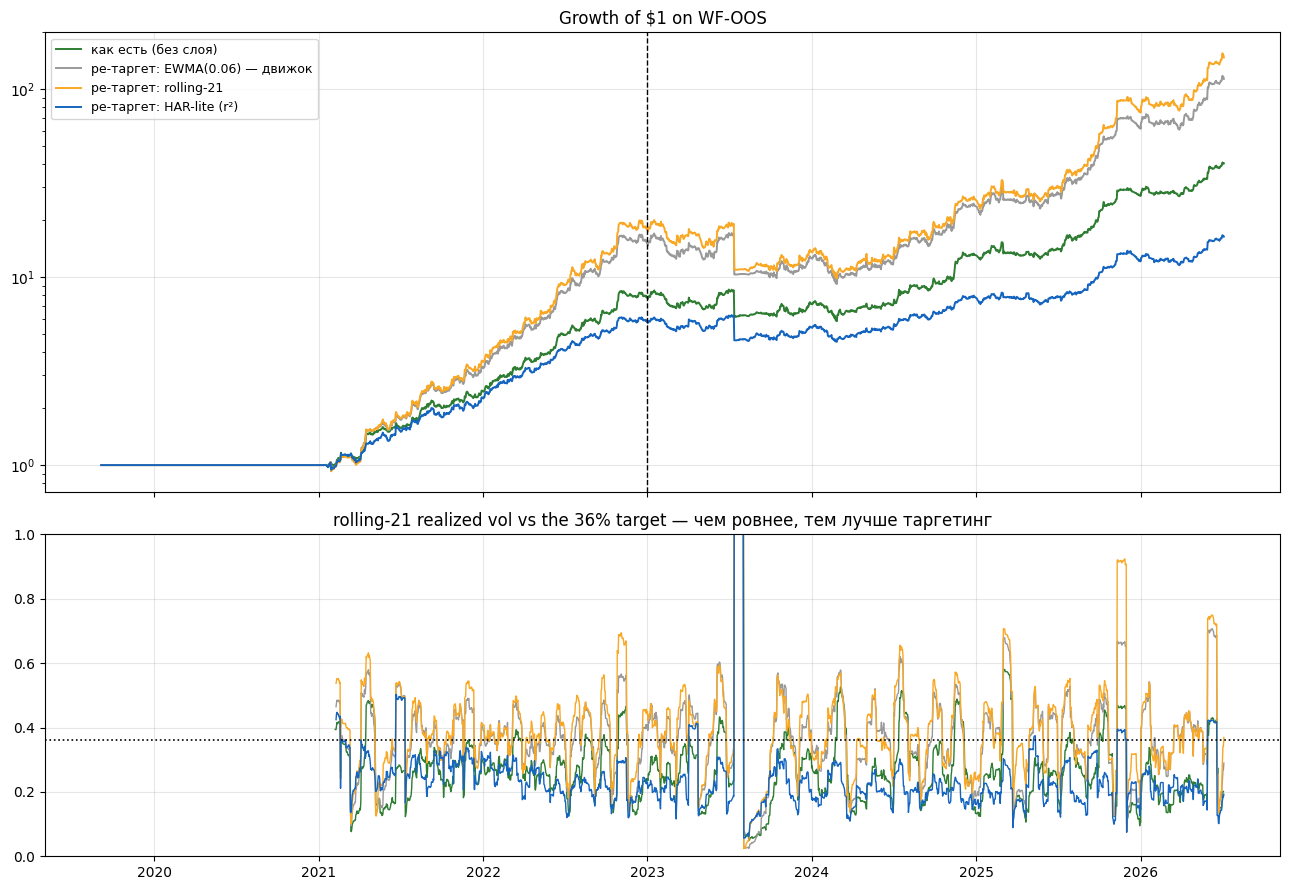

In [6]:
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                              gridspec_kw={'height_ratios': [2, 1.4]})
cols = {'как есть (без слоя)': '#2e7d32', 'ре-таргет: EWMA(0.06) — движок': '#999999',
        'ре-таргет: rolling-21': '#f9a825', 'ре-таргет: HAR-lite (r²)': '#1565c0'}
for name, rr in cand.items():
    x = rr.fillna(0.0)
    ax.plot(idx, (1 + x).cumprod(), lw=1.4, color=cols.get(name, '#000'), label=name)
ax.set_yscale('log'); ax.grid(alpha=0.3); ax.legend(fontsize=9, loc='upper left')
ax.axvline(TE, color='k', ls='--', lw=1)
ax.set_title('Growth of $1 on WF-OOS')
for name, rr in cand.items():
    rl = rr.rolling(21).std() * np.sqrt(ANN)
    ax2.plot(idx, rl, lw=1.0, color=cols.get(name, '#000'))
ax2.axhline(VOL, color='k', lw=1.2, ls=':')
ax2.set_ylim(0, 1.0); ax2.grid(alpha=0.3)
ax2.set_title('rolling-21 realized vol vs the 36% target — чем ровнее, тем лучше таргетинг')
plt.tight_layout(); plt.show()

## 4. Как читать

- **Таблица 1 (QLIKE)** — главный судья прогнозов. HAR должен бить EWMA на
  учебном BTC-случае с настоящей RV (это его домашнее поле). На портфельном r²-прокси
  разрыв будет меньше — прокси шумный.
- **Таблица 3 (деньги)**: смотри «вола-ошибку» — насколько ровно ряд держит 36%.
  Sharpe у слоёв ре-таргетинга может быть ~равным (вола-таргетинг не создаёт edge,
  он контролирует риск) — выигрыш ищется в стабильности волы и maxDD.
- Если HAR даёт ощутимо меньшую вола-ошибку при том же Sharpe — имеет смысл нести
  его в fastsim/движок как опцию таргетинга (phase 2). Если разница косметическая —
  EWMA остаётся: она проще и уже в проде.

## 5. Вердикт (по факту прогона)

1. **На портфеле (дневной r²-прокси): EWMA движка уже лучшая** — QLIKE −7.091 против
   −7.027 у HAR-lite и −6.879 у rolling-21. На шумном дневном прокси трём
   коэффициентам HAR учиться не на чем.
2. **На BTC с настоящей внутридневной RV HAR выигрывает** (QLIKE −6.498 vs −6.447,
   MSE −9%) — учебник подтверждён: вола прогнозируема, HAR лучше, но только когда
   его кормят честной RV из интрадей-баров.
3. **Деньги: второй слой таргетинга не нужен.** Портфель «как есть» — Sharpe 2.37 /
   dd −32%; все ре-таргеты хуже по Sharpe, вола-ошибку почти не снижают, а EWMA/rolling
   ещё и углубляют просадку (−46/−51%) из-за плеча в спокойные периоды.

**Практический итог:** EWMA в проде остаётся. Единственный осмысленный апгрейд на
будущее — не менять формулу, а **сменить вход**: подавать в движок per-asset дневную
RV, посчитанную из 1h-баров (данные уже есть в data_1h.pickle). Это phase-2 идея для
движка, не слой поверх.